# 02 全市场分群与机器学习（Market Segmentation with ML）

## 本 Notebook 目标

本阶段将在 01 中获取和清洗的 UN Comtrade 数据基础上，
构建面向机器学习的“全市场特征矩阵”（Feature Matrix）。

### 核心思路

机器学习不能直接理解“越南市场很好”“德国市场规模很大”这样的业务描述，
因此需要把每一个出口目的国转化成一组可以计算的数值特征。

最终数据结构为：

- 一行（Row）= 一个出口目的国 / 市场
- 一列（Feature）= 一个市场特征

例如：

| 市场 | 出口规模 | 同比增长 | 近期动量 | 月度波动 | 中国市场份额 |
|---|---:|---:|---:|---:|---:|
| Viet Nam | ... | ... | ... | ... | ... |
| Germany | ... | ... | ... | ... | ... |
| India | ... | ... | ... | ... | ... |

数学上可以表示为特征矩阵：

\[
X =
\begin{pmatrix}
x_{11} & x_{12} & \cdots & x_{1p}\\
x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & & \vdots\\
x_{n1} & x_{n2} & \cdots & x_{np}
\end{pmatrix}
\]

其中：

- \(n\)：市场数量
- \(p\)：市场特征数量
- \(X\)：后续机器学习模型真正使用的数据

## 后续任务

1. 构建全市场 Feature Matrix
2. 特征清洗与异常值处理
3. 特征标准化（Standardization）
4. 使用 K-Means 进行市场聚类
5. 使用 PCA 对聚类结果进行二维可视化
6. 根据业务指标解释不同市场群组
7. 识别高潜力出口市场

本项目采用的是无监督学习（Unsupervised Learning）。

因为我们并没有提前人为规定：
“哪个国家一定属于高潜力市场”。

模型将根据不同市场之间的特征相似程度自动进行分组。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# --------------------------------------------------
# Project paths
# --------------------------------------------------

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Notebook directory :", NOTEBOOK_DIR)
print("Project root       :", PROJECT_ROOT)
print("Raw data directory :", RAW_DIR)
print("Processed directory:", PROCESSED_DIR)

Notebook directory : ./notebooks
Project root       : .
Raw data directory : ./data/raw
Processed directory: ./data/processed


In [2]:
processed_files = []

for file in sorted(PROCESSED_DIR.iterdir()):
    if file.is_file():
        processed_files.append(
            {
                "file_name": file.name,
                "suffix": file.suffix,
                "size_kb": file.stat().st_size / 1024
            }
        )

processed_files = pd.DataFrame(processed_files)

processed_files

,file_name,suffix,size_kb
0,china_hs850760_country_year_2023_2024.csv,.csv,17.3945
1,china_hs850760_partner_monthly_2023_2024.csv,.csv,210.0518


In [3]:
all_processed_files = []

for file in sorted(PROCESSED_DIR.rglob("*")):
    if file.is_file():
        all_processed_files.append(
            {
                "relative_path": file.relative_to(PROJECT_ROOT),
                "suffix": file.suffix,
                "size_kb": file.stat().st_size / 1024
            }
        )

all_processed_files = pd.DataFrame(all_processed_files)

all_processed_files

,relative_path,suffix,size_kb
0,data\processed\china_hs850760_country_year_202...,.csv,17.3945
1,data\processed\china_hs850760_partner_monthly_...,.csv,210.0518


## 1. 读取全市场基础数据

本阶段以 01 中已经清洗并保存的月度目的国数据作为主要数据源。

数据粒度为：

> 一个目的国 × 一个月 = 一条记录

后续特征工程的目标，是将月度明细数据聚合为：

> 一个目的国 = 一个机器学习样本

因此，这一步首先需要确认数据的字段、粒度以及市场唯一标识。

In [4]:
monthly_path = (
    PROCESSED_DIR
    / "china_hs850760_partner_monthly_2023_2024.csv"
)

annual_path = (
    PROCESSED_DIR
    / "china_hs850760_country_year_2023_2024.csv"
)

partner_monthly = pd.read_csv(monthly_path)
country_year = pd.read_csv(annual_path)

print("partner_monthly shape:", partner_monthly.shape)
print("country_year shape   :", country_year.shape)

partner_monthly shape: (4194, 7)
country_year shape   : (206, 7)


In [5]:
print("=== partner_monthly columns ===")
print(partner_monthly.columns.tolist())

print("\n=== country_year columns ===")
print(country_year.columns.tolist())

=== partner_monthly columns ===
['period', 'destination_code', 'destination_iso', 'destination', 'export_value_usd', 'month', 'year']

=== country_year columns ===
['destination_code', 'destination', '2023', '2024', 'growth_2024', 'export_share_2024', 'export_increment_2024']


In [6]:
partner_monthly.head()

,period,destination_code,destination_iso,destination,export_value_usd,month,year
0,202301,8,ALB,Albania,"9,267.0000",2023-01-01,2023
1,202301,12,DZA,Algeria,"1,916,905.0000",2023-01-01,2023
2,202301,24,AGO,Angola,"5,183.0000",2023-01-01,2023
3,202301,28,ATG,Antigua and Barbuda,"11,191.0000",2023-01-01,2023
4,202301,32,ARG,Argentina,"2,783,946.0000",2023-01-01,2023


In [7]:
country_year.head()

,destination_code,destination,2023,2024,growth_2024,export_share_2024,export_increment_2024
0,842,USA,"13,564,931,937.0000","15,336,139,169.0000",0.1306,0.2509,"1,771,207,232.0000"
1,276,Germany,"9,335,448,251.0000","10,254,026,944.0000",0.0984,0.1677,"918,578,693.0000"
2,410,Rep. of Korea,"7,850,429,969.0000","3,788,155,735.0000",-0.5175,0.0620,"-4,062,274,234.0000"
3,704,Viet Nam,"3,284,244,905.0000","3,709,583,575.0000",0.1295,0.0607,"425,338,670.0000"
4,528,Netherlands,"3,639,931,136.0000","2,407,019,653.0000",-0.3387,0.0394,"-1,232,911,483.0000"


## 2. 确定样本粒度并构建完整月份面板

机器学习中的一个核心概念是“样本（Sample）”。

本项目最终希望：

> 一个出口目的国 = 一个机器学习样本

但当前月度数据的粒度是：

> 一个目的国 × 一个月 = 一条记录

因此，在构造市场级特征之前，需要先检查：

1. 市场-月份组合是否唯一
2. 每个市场是否都有完整的 24 个月记录
3. 对没有出口记录的月份进行合理补齐

这样才能正确计算市场的月均出口、波动性、活跃月份数和近期增长动量等指标。

In [8]:
# month 转换为真正的日期类型
partner_monthly["month"] = pd.to_datetime(partner_monthly["month"])

# 检查：一个市场在同一个月是否出现重复记录
duplicate_count = partner_monthly.duplicated(
    subset=["destination_code", "month"]
).sum()

market_count = country_year["destination_code"].nunique()
month_count = partner_monthly["month"].nunique()

expected_rows = market_count * month_count
actual_rows = len(partner_monthly)

print("市场数量:", market_count)
print("月份数量:", month_count)
print("理论完整行数:", expected_rows)
print("实际行数:", actual_rows)
print("缺少的市场-月份组合:", expected_rows - actual_rows)
print("重复市场-月份记录:", duplicate_count)

市场数量: 206
月份数量: 24
理论完整行数: 4944
实际行数: 4194
缺少的市场-月份组合: 750
重复市场-月份记录: 0


In [9]:
market_month_coverage = (
    partner_monthly
    .groupby(["destination_code", "destination"])
    .agg(
        observed_months=("month", "nunique")
    )
    .reset_index()
    .sort_values("observed_months")
)

market_month_coverage.head(10)

,destination_code,destination,observed_months
14,60,Bermuda,1
57,234,Faroe Isds,1
190,798,Tuvalu,1
109,473,"LAIA, nes",3
138,585,Palau,3
157,674,San Marino,3
134,577,"Other Africa, nes",3
121,520,Nauru,3
41,184,Cook Isds,4
22,92,Br. Virgin Isds,4


In [10]:
market_month_coverage["observed_months"].describe()

count   206.0000
mean     20.3592
std       6.3758
min       1.0000
25%      20.0000
50%      24.0000
75%      24.0000
max      24.0000
Name: observed_months, dtype: float64

In [11]:
# --------------------------------------------------
# 构建完整 Market × Month 面板
# --------------------------------------------------

# 所有市场
all_markets = (
    country_year[
        ["destination_code", "destination"]
    ]
    .drop_duplicates()
)

# 2023-01 至 2024-12，共 24 个月
all_months = pd.DataFrame(
    {
        "month": pd.date_range(
            start="2023-01-01",
            end="2024-12-01",
            freq="MS"
        )
    }
)

# 笛卡尔积：每个市场都配上完整的24个月
full_panel = all_markets.merge(
    all_months,
    how="cross"
)

print(full_panel.shape)

full_panel.head()

(4944, 3)


,destination_code,destination,month
0,842,USA,2023-01-01
1,842,USA,2023-02-01
2,842,USA,2023-03-01
3,842,USA,2023-04-01
4,842,USA,2023-05-01


In [12]:
monthly_values = partner_monthly[
    [
        "destination_code",
        "month",
        "export_value_usd"
    ]
].copy()

full_panel = full_panel.merge(
    monthly_values,
    on=["destination_code", "month"],
    how="left"
)

full_panel.head()

,destination_code,destination,month,export_value_usd
0,842,USA,2023-01-01,"1,348,053,642.0000"
1,842,USA,2023-02-01,"830,253,723.0000"
2,842,USA,2023-03-01,"1,102,115,190.0000"
3,842,USA,2023-04-01,"1,062,639,424.0000"
4,842,USA,2023-05-01,"1,028,100,905.0000"


In [13]:
full_panel["export_value_usd"].isna().sum()

np.int64(750)

In [14]:
full_panel["export_value_usd"] = (
    full_panel["export_value_usd"]
    .fillna(0)
)

full_panel["year"] = full_panel["month"].dt.year
full_panel["month_num"] = full_panel["month"].dt.month

full_panel.head()

,destination_code,destination,month,export_value_usd,year,month_num
0,842,USA,2023-01-01,"1,348,053,642.0000",2023,1
1,842,USA,2023-02-01,"830,253,723.0000",2023,2
2,842,USA,2023-03-01,"1,102,115,190.0000",2023,3
3,842,USA,2023-04-01,"1,062,639,424.0000",2023,4
4,842,USA,2023-05-01,"1,028,100,905.0000",2023,5


In [15]:
print("完整面板行数:", len(full_panel))

print(
    "重复市场-月份:",
    full_panel.duplicated(
        subset=["destination_code", "month"]
    ).sum()
)

print(
    "缺失出口额:",
    full_panel["export_value_usd"].isna().sum()
)

完整面板行数: 4944
重复市场-月份: 0
缺失出口额: 0


In [16]:
panel_2024 = full_panel[
    full_panel["year"] == 2024
].copy()

panel_2024.shape

(2472, 6)

In [17]:
monthly_features = (
    panel_2024
    .groupby(
        ["destination_code", "destination"],
        as_index=False
    )
    .agg(
        export_2024_from_months=(
            "export_value_usd",
            "sum"
        ),

        avg_monthly_export_2024=(
            "export_value_usd",
            "mean"
        ),

        std_monthly_export_2024=(
            "export_value_usd",
            "std"
        ),

        active_months_2024=(
            "export_value_usd",
            lambda x: (x > 0).sum()
        )
    )
)

monthly_features.head()

,destination_code,destination,export_2024_from_months,avg_monthly_export_2024,std_monthly_export_2024,active_months_2024
0,4,Afghanistan,"2,533,001.0000","211,083.4167","212,687.2710",9
1,8,Albania,"568,342.0000","47,361.8333","59,951.5311",12
2,12,Algeria,"11,727,414.0000","977,284.5000","928,040.3709",12
3,20,Andorra,"27,409.0000","2,284.0833","7,139.1694",3
4,24,Angola,"2,960,042.0000","246,670.1667","339,147.3899",12


In [18]:
monthly_features["active_month_ratio_2024"] = (
    monthly_features["active_months_2024"] / 12
)

In [19]:
monthly_features["monthly_cv_2024"] = (
    monthly_features["std_monthly_export_2024"]
    /
    monthly_features["avg_monthly_export_2024"]
)

In [20]:
monthly_features[
    [
        "destination",
        "export_2024_from_months",
        "active_month_ratio_2024",
        "monthly_cv_2024"
    ]
].head(10)

,destination,export_2024_from_months,active_month_ratio_2024,monthly_cv_2024
0,Afghanistan,"2,533,001.0000",0.7500,1.0076
1,Albania,"568,342.0000",1.0000,1.2658
2,Algeria,"11,727,414.0000",1.0000,0.9496
3,Andorra,"27,409.0000",0.2500,3.1256
4,Angola,"2,960,042.0000",1.0000,1.3749
5,Antigua and Barbuda,"267,914.0000",0.7500,1.3417
6,Argentina,"59,541,963.0000",1.0000,0.9272
7,Australia,"1,456,510,643.0000",1.0000,0.6845
8,Austria,"182,795,717.0000",1.0000,0.6301
9,Bahamas,"958,012.0000",1.0000,1.2374


## 3. 构造市场增长动量特征

年度同比增长率可以反映市场的中期增长趋势，
但无法判断市场最近是否仍在持续增长。

因此进一步将 2024 年划分为：

- H1：1—6 月
- H2：7—12 月

并构造下半年相对于上半年的增长率：

$$
\mathrm{Momentum}_{H2/H1}
=
\frac{H2-H1}{H1}
$$

该指标用于衡量市场在 2024 年内部的近期增长动量。

- 大于 0：下半年较上半年增长
- 小于 0：下半年较上半年下降
- 越大：近期增长动量越强

In [21]:
# 计算每个市场 2024 上半年 / 下半年出口额

h1_h2_features = (
    panel_2024
    .assign(
        half=np.where(
            panel_2024["month_num"] <= 6,
            "H1",
            "H2"
        )
    )
    .pivot_table(
        index=["destination_code", "destination"],
        columns="half",
        values="export_value_usd",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

h1_h2_features.head()

half,destination_code,destination,H1,H2
0,4,Afghanistan,"943,259.0000","1,589,742.0000"
1,8,Albania,"431,075.0000","137,267.0000"
2,12,Algeria,"6,326,390.0000","5,401,024.0000"
3,20,Andorra,"24,875.0000","2,534.0000"
4,24,Angola,"1,580,454.0000","1,379,588.0000"


In [22]:
h1_h2_features["h2_h1_momentum_2024"] = np.where(
    h1_h2_features["H1"] > 0,
    (
        h1_h2_features["H2"]
        - h1_h2_features["H1"]
    )
    / h1_h2_features["H1"],
    np.nan
)

h1_h2_features[
    [
        "destination",
        "H1",
        "H2",
        "h2_h1_momentum_2024"
    ]
].head(10)

half,destination,H1,H2,h2_h1_momentum_2024
0,Afghanistan,"943,259.0000","1,589,742.0000",0.6854
1,Albania,"431,075.0000","137,267.0000",-0.6816
2,Algeria,"6,326,390.0000","5,401,024.0000",-0.1463
3,Andorra,"24,875.0000","2,534.0000",-0.8981
4,Angola,"1,580,454.0000","1,379,588.0000",-0.1271
5,Antigua and Barbuda,"104,056.0000","163,858.0000",0.5747
6,Argentina,"28,706,978.0000","30,834,985.0000",0.0741
7,Australia,"358,567,101.0000","1,097,943,542.0000",2.0620
8,Austria,"56,557,922.0000","126,237,795.0000",1.2320
9,Bahamas,"313,307.0000","644,705.0000",1.0577


In [23]:
export_reconciliation = monthly_features[
    [
        "destination_code",
        "destination",
        "export_2024_from_months"
    ]
].merge(
    country_year[
        [
            "destination_code",
            "2024"
        ]
    ],
    on="destination_code",
    how="left"
)

export_reconciliation["difference"] = (
    export_reconciliation["export_2024_from_months"]
    - export_reconciliation["2024"]
)

export_reconciliation["abs_difference"] = (
    export_reconciliation["difference"].abs()
)

export_reconciliation.sort_values(
    "abs_difference",
    ascending=False
)[
    [
        "destination",
        "export_2024_from_months",
        "2024",
        "difference",
        "abs_difference"
    ]
].head(10)

,destination,export_2024_from_months,2024,difference,abs_difference
0,Afghanistan,"2,533,001.0000","2,533,001.0000",0.0000,0.0000
1,Albania,"568,342.0000","568,342.0000",0.0000,0.0000
2,Algeria,"11,727,414.0000","11,727,414.0000",0.0000,0.0000
3,Andorra,"27,409.0000","27,409.0000",0.0000,0.0000
4,Angola,"2,960,042.0000","2,960,042.0000",0.0000,0.0000
5,Antigua and Barbuda,"267,914.0000","267,914.0000",0.0000,0.0000
6,Argentina,"59,541,963.0000","59,541,963.0000",0.0000,0.0000
7,Australia,"1,456,510,643.0000","1,456,510,643.0000",0.0000,0.0000
8,Austria,"182,795,717.0000","182,795,717.0000",0.0000,0.0000
9,Bahamas,"958,012.0000","958,012.0000",0.0000,0.0000


## 4. 构建第一版市场特征矩阵

经过前面的特征工程，目前已经从不同角度描述一个出口市场：

- **市场规模（Scale）**：2024 年出口额
- **年度增长（Growth）**：2024 年同比增长率
- **近期动量（Momentum）**：2024 年下半年相对于上半年的增长率
- **市场稳定性（Stability）**：月度出口变异系数 CV
- **贸易连续性（Continuity）**：2024 年有出口记录的月份比例

接下来将这些市场级指标合并为一张特征表。

其中：

- 一行代表一个出口目的国，即一个样本（Sample）
- 一列代表一个市场特征（Feature）
- 国家名称和国家代码仅作为标识字段，不参与模型计算

该特征表将作为后续机器学习聚类的基础。

In [24]:
market_feature_table = (
    monthly_features[
        [
            "destination_code",
            "destination",
            "export_2024_from_months",
            "monthly_cv_2024",
            "active_month_ratio_2024"
        ]
    ]
    .merge(
        h1_h2_features[
            [
                "destination_code",
                "h2_h1_momentum_2024"
            ]
        ],
        on="destination_code",
        how="left"
    )
    .merge(
        country_year[
            [
                "destination_code",
                "growth_2024"
            ]
        ],
        on="destination_code",
        how="left"
    )
)

# 名字稍微简化
market_feature_table = market_feature_table.rename(
    columns={
        "export_2024_from_months": "export_2024"
    }
)

market_feature_table.head(10)

,destination_code,destination,export_2024,monthly_cv_2024,active_month_ratio_2024,h2_h1_momentum_2024,growth_2024
0,4,Afghanistan,"2,533,001.0000",1.0076,0.7500,0.6854,0.0614
1,8,Albania,"568,342.0000",1.2658,1.0000,-0.6816,-0.2098
2,12,Algeria,"11,727,414.0000",0.9496,1.0000,-0.1463,-0.3686
3,20,Andorra,"27,409.0000",3.1256,0.2500,-0.8981,-0.5935
4,24,Angola,"2,960,042.0000",1.3749,1.0000,-0.1271,0.1749
5,28,Antigua and Barbuda,"267,914.0000",1.3417,0.7500,0.5747,0.2984
6,32,Argentina,"59,541,963.0000",0.9272,1.0000,0.0741,-0.1363
7,36,Australia,"1,456,510,643.0000",0.6845,1.0000,2.0620,1.0122
8,40,Austria,"182,795,717.0000",0.6301,1.0000,1.2320,-0.5380
9,44,Bahamas,"958,012.0000",1.2374,1.0000,1.0577,0.9046


In [25]:
feature_columns = [
    "export_2024",
    "growth_2024",
    "h2_h1_momentum_2024",
    "monthly_cv_2024",
    "active_month_ratio_2024"
]

X = market_feature_table[
    feature_columns
].copy()

print("市场特征表 shape:", market_feature_table.shape)
print("机器学习特征矩阵 X shape:", X.shape)

X.head()

市场特征表 shape: (206, 7)
机器学习特征矩阵 X shape: (206, 5)


,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
0,"2,533,001.0000",0.0614,0.6854,1.0076,0.7500
1,"568,342.0000",-0.2098,-0.6816,1.2658,1.0000
2,"11,727,414.0000",-0.3686,-0.1463,0.9496,1.0000
3,"27,409.0000",-0.5935,-0.8981,3.1256,0.2500
4,"2,960,042.0000",0.1749,-0.1271,1.3749,1.0000


In [26]:
feature_quality = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_ratio": X.isna().mean(),
    "min": X.min(),
    "max": X.max(),
    "mean": X.mean()
})

feature_quality

,missing_count,missing_ratio,min,max,mean
export_2024,0,0.0000,0.0000,"15,336,139,169.0000","296,732,635.3107"
growth_2024,8,0.0388,-0.9937,"5,634.7834",30.1567
h2_h1_momentum_2024,6,0.0291,-1.0000,35.0596,1.8572
monthly_cv_2024,4,0.0194,0.1227,3.4641,1.1560
active_month_ratio_2024,0,0.0000,0.0000,1.0000,0.8629


In [27]:
pd.Series(
    np.isinf(X).sum(),
    index=X.columns,
    name="inf_count"
)

export_2024                0
growth_2024                0
h2_h1_momentum_2024        0
monthly_cv_2024            0
active_month_ratio_2024    0
Name: inf_count, dtype: int64

## 5. 特征质量诊断

在将特征输入机器学习模型之前，需要检查：

1. 缺失值产生的业务原因
2. 极端增长率是否受到低基数效应影响
3. 各特征的分布是否存在严重偏态
4. 是否需要进行特征变换

机器学习模型不会自动理解异常数值背后的业务含义，
因此不能简单地将所有数值直接输入模型。

In [28]:
# 找出至少存在一个缺失特征的市场

missing_markets = market_feature_table[
    market_feature_table[feature_columns]
    .isna()
    .any(axis=1)
].copy()

missing_markets[
    [
        "destination",
        "export_2024",
        "growth_2024",
        "h2_h1_momentum_2024",
        "monthly_cv_2024",
        "active_month_ratio_2024"
    ]
]

,destination,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
14,Bermuda,"25,775.0000",NaN,-1.0000,3.4641,0.0833
57,Faroe Isds,"195,548.0000",NaN,-1.0000,3.4641,0.0833
109,"LAIA, nes",0.0000,NaN,NaN,NaN,0.0000
121,Nauru,"2,349,396.0000",NaN,22.2719,3.3017,0.2500
133,"Other Europe, nes",413.0000,NaN,1.3306,1.2633,0.5000
134,"Other Africa, nes",0.0000,NaN,NaN,NaN,0.0000
138,Palau,0.0000,NaN,NaN,NaN,0.0000
154,Saint Kitts and Nevis,"71,230.0000",-0.0600,NaN,2.8006,0.2500
157,San Marino,"4,650.0000",-0.7901,NaN,3.4641,0.0833
190,Tuvalu,0.0000,NaN,NaN,NaN,0.0000


In [29]:
market_feature_table[
    [
        "destination",
        "export_2024",
        "growth_2024"
    ]
].sort_values(
    "growth_2024",
    ascending=False
).head(15)

,destination,export_2024,growth_2024
38,Comoros,"1,769,636.0000","5,634.7834"
183,Tonga,"333,114.0000",125.9973
97,Latvia,"46,507,639.0000",35.0753
96,Lesotho,"1,577,600.0000",30.5861
161,Serbia,"36,997,999.0000",20.0726
200,Uzbekistan,"146,837,513.0000",13.3031
147,Guinea-Bissau,"1,386,295.0000",9.1794
125,Curaçao,"6,846,330.0000",8.6053
204,Zambia,"34,999,502.0000",7.0632
201,Venezuela,"10,764,779.0000",5.9300


In [30]:
market_feature_table[
    [
        "destination",
        "export_2024",
        "h2_h1_momentum_2024"
    ]
].sort_values(
    "h2_h1_momentum_2024",
    ascending=False
).head(15)

,destination,export_2024,h2_h1_momentum_2024
55,Eritrea,"1,536,860.0000",35.0596
114,Mongolia,"63,852,471.0000",34.7817
44,Cuba,"4,590,369.0000",27.3889
125,Curaçao,"6,846,330.0000",22.6663
121,Nauru,"2,349,396.0000",22.2719
49,Dominica,"1,257,534.0000",19.8208
137,Marshall Isds,"4,104.0000",17.2676
136,FS Micronesia,"437,289.0000",15.9334
200,Uzbekistan,"146,837,513.0000",14.5531
63,Gabon,"2,029,572.0000",11.0998


In [31]:
X.describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
export_2024,206.0000,"296,732,635.3107","1,363,676,525.5593",0.0000,0.0000,"26,183.5000","1,102,876.5000","6,958,640.0000","50,588,564.5000","1,118,919,405.5000","3,784,227,127.0000","15,336,139,169.0000"
growth_2024,198.0000,30.1567,400.4430,-0.9937,-0.9767,-0.6473,-0.1980,0.1412,0.8881,5.8001,37.8030,"5,634.7834"
h2_h1_momentum_2024,200.0000,1.8572,5.3046,-1.0000,-0.9731,-0.6964,-0.0770,0.2650,1.2479,10.7792,27.4628,35.0596
monthly_cv_2024,202.0000,1.1560,0.8179,0.1227,0.1460,0.2171,0.5209,1.0115,1.6034,2.9252,3.4630,3.4641
active_month_ratio_2024,206.0000,0.8629,0.2673,0.0000,0.0000,0.2500,0.9167,1.0000,1.0000,1.0000,1.0000,1.0000


## 6. 极端增长率与低基数效应检查

增长率是一个相对指标：

$$
Growth =
\frac{Export_{2024}-Export_{2023}}
{Export_{2023}}
$$

当上一期出口额非常小时，即使本期增加的绝对金额并不大，
也可能产生极端高的增长率。

因此，在对增长率进行特征变换之前，
需要先检查高增长市场的上一期基数，
判断极端增长是否主要由低基数效应造成。

In [32]:
growth_diagnosis = market_feature_table[
    [
        "destination_code",
        "destination",
        "export_2024",
        "growth_2024"
    ]
].merge(
    country_year[
        [
            "destination_code",
            "2023"
        ]
    ],
    on="destination_code",
    how="left"
)

growth_diagnosis = growth_diagnosis.rename(
    columns={
        "2023": "export_2023"
    }
)

growth_diagnosis[
    [
        "destination",
        "export_2023",
        "export_2024",
        "growth_2024"
    ]
].sort_values(
    "growth_2024",
    ascending=False
).head(20)

,destination,export_2023,export_2024,growth_2024
38,Comoros,314.0000,"1,769,636.0000","5,634.7834"
183,Tonga,"2,623.0000","333,114.0000",125.9973
97,Latvia,"1,289,182.0000","46,507,639.0000",35.0753
96,Lesotho,"49,946.0000","1,577,600.0000",30.5861
161,Serbia,"1,755,741.0000","36,997,999.0000",20.0726
200,Uzbekistan,"10,266,097.0000","146,837,513.0000",13.3031
147,Guinea-Bissau,"136,186.0000","1,386,295.0000",9.1794
125,Curaçao,"712,768.0000","6,846,330.0000",8.6053
204,Zambia,"4,340,651.0000","34,999,502.0000",7.0632
201,Venezuela,"1,553,354.0000","10,764,779.0000",5.9300


In [33]:
h1_h2_features[
    [
        "destination",
        "H1",
        "H2",
        "h2_h1_momentum_2024"
    ]
].sort_values(
    "h2_h1_momentum_2024",
    ascending=False
).head(20)

half,destination,H1,H2,h2_h1_momentum_2024
55,Eritrea,"41,470.0000","1,495,390.0000",35.0596
114,Mongolia,"1,735,985.0000","62,116,486.0000",34.7817
44,Cuba,"156,194.0000","4,434,175.0000",27.3889
125,Curaçao,"277,558.0000","6,568,772.0000",22.6663
121,Nauru,"96,795.0000","2,252,601.0000",22.2719
49,Dominica,"57,630.0000","1,199,904.0000",19.8208
137,Marshall Isds,213.0000,"3,891.0000",17.2676
136,FS Micronesia,"24,384.0000","412,905.0000",15.9334
200,Uzbekistan,"8,870,712.0000","137,966,801.0000",14.5531
63,Gabon,"154,932.0000","1,874,640.0000",11.0998


## 7. 对规模、增长和动量进行对数变换

出口额、年度增长率和半年增长动量均存在明显的右偏或低基数效应。

为了避免少数极端市场过度支配后续基于距离的聚类模型，
对相关特征进行对数变换。

### 规模特征

使用：

$$
\log(1+Export_{2024})
$$

压缩不同市场之间巨大的出口规模差异，同时保留市场规模排序。

### 年度增长特征

使用对数增长比：

$$
Growth_{log}
=
\log(1+Export_{2024})
-
\log(1+Export_{2023})
$$

### 近期动量特征

类似地：

$$
Momentum_{log}
=
\log(1+H2)
-
\log(1+H1)
$$

相比普通增长率，对数增长比能够显著减弱低基数效应，
并使同比例的增长和下降在数值上更加对称。

In [34]:
market_feature_model = (
    market_feature_table
    .merge(
        country_year[
            [
                "destination_code",
                "2023"
            ]
        ],
        on="destination_code",
        how="left"
    )
    .merge(
        h1_h2_features[
            [
                "destination_code",
                "H1",
                "H2"
            ]
        ],
        on="destination_code",
        how="left"
    )
    .rename(
        columns={
            "2023": "export_2023"
        }
    )
)

market_feature_model.head()

,destination_code,destination,export_2024,monthly_cv_2024,active_month_ratio_2024,h2_h1_momentum_2024,growth_2024,export_2023,H1,H2
0,4,Afghanistan,"2,533,001.0000",1.0076,0.7500,0.6854,0.0614,"2,386,507.0000","943,259.0000","1,589,742.0000"
1,8,Albania,"568,342.0000",1.2658,1.0000,-0.6816,-0.2098,"719,209.0000","431,075.0000","137,267.0000"
2,12,Algeria,"11,727,414.0000",0.9496,1.0000,-0.1463,-0.3686,"18,573,541.0000","6,326,390.0000","5,401,024.0000"
3,20,Andorra,"27,409.0000",3.1256,0.2500,-0.8981,-0.5935,"67,429.0000","24,875.0000","2,534.0000"
4,24,Angola,"2,960,042.0000",1.3749,1.0000,-0.1271,0.1749,"2,519,493.0000","1,580,454.0000","1,379,588.0000"


In [35]:
# 无贸易记录的年度金额按 0 处理
market_feature_model["export_2023"] = (
    market_feature_model["export_2023"]
    .fillna(0)
)

# --------------------------------------------------
# Feature Transformation
# --------------------------------------------------

# 规模：对数出口额
market_feature_model["log_export_2024"] = np.log1p(
    market_feature_model["export_2024"]
)

# 年度增长：对数增长比
market_feature_model["growth_log_ratio"] = (
    np.log1p(market_feature_model["export_2024"])
    -
    np.log1p(market_feature_model["export_2023"])
)

# 近期动量：对数 H2/H1
market_feature_model["momentum_log_ratio"] = (
    np.log1p(market_feature_model["H2"])
    -
    np.log1p(market_feature_model["H1"])
)

In [36]:
market_feature_model[
    [
        "destination",
        "export_2023",
        "export_2024",
        "growth_2024",
        "growth_log_ratio"
    ]
].sort_values(
    "growth_2024",
    ascending=False
).head(15)

,destination,export_2023,export_2024,growth_2024,growth_log_ratio
38,Comoros,314.0000,"1,769,636.0000","5,634.7834",8.6337
183,Tonga,"2,623.0000","333,114.0000",125.9973,4.8438
97,Latvia,"1,289,182.0000","46,507,639.0000",35.0753,3.5856
96,Lesotho,"49,946.0000","1,577,600.0000",30.5861,3.4527
161,Serbia,"1,755,741.0000","36,997,999.0000",20.0726,3.0480
200,Uzbekistan,"10,266,097.0000","146,837,513.0000",13.3031,2.6605
147,Guinea-Bissau,"136,186.0000","1,386,295.0000",9.1794,2.3204
125,Curaçao,"712,768.0000","6,846,330.0000",8.6053,2.2623
204,Zambia,"4,340,651.0000","34,999,502.0000",7.0632,2.0873
201,Venezuela,"1,553,354.0000","10,764,779.0000",5.9300,1.9359


In [37]:
non_market_rows = market_feature_model[
    market_feature_model["destination"]
    .str.contains(
        "nes",
        case=False,
        na=False
    )
]

non_market_rows[
    [
        "destination_code",
        "destination",
        "export_2024"
    ]
]

,destination_code,destination,export_2024
61,258,French Polynesia,"7,492,319.0000"
79,360,Indonesia,"439,934,833.0000"
109,473,"LAIA, nes",0.0000
113,490,"Other Asia, nes","685,684,320.0000"
123,527,"Oceania, nes","489,323.0000"
133,568,"Other Europe, nes",413.0000
134,577,"Other Africa, nes",0.0000
136,583,FS Micronesia,"437,289.0000"
144,608,Philippines,"141,528,229.0000"
150,636,"Rest of America, nes","752,560.0000"


In [38]:
non_market_rows = market_feature_model[
    market_feature_model["destination"]
    .str.contains(
        r"\bnes\b",
        case=False,
        na=False,
        regex=True
    )
].copy()

non_market_rows[
    [
        "destination_code",
        "destination",
        "export_2024"
    ]
]

,destination_code,destination,export_2024
109,473,"LAIA, nes",0.0000
113,490,"Other Asia, nes","685,684,320.0000"
123,527,"Oceania, nes","489,323.0000"
133,568,"Other Europe, nes",413.0000
134,577,"Other Africa, nes",0.0000
150,636,"Rest of America, nes","752,560.0000"
205,899,"Areas, nes","2,944,608.0000"


## 8. 确定机器学习建模市场范围

完整特征表中既包含真实出口市场，也包含部分 UN Comtrade 的区域性或未具体归类项目。

为了避免聚类结果受到非真实市场记录影响，
将完整数据表与机器学习建模样本分开保存。

建模样本目前满足：

1. 必须是具体的目的市场，而不是 `nes` 等聚合类别
2. 2024 年必须存在实际出口记录

完整市场数据仍然保留，仅在模型训练阶段进行筛选。

In [39]:
# --------------------------------------------------
# 排除非具体市场的 nes 聚合项
# --------------------------------------------------

is_non_market = (
    market_feature_model["destination"]
    .str.contains(
        r"\bnes\b",
        case=False,
        na=False,
        regex=True
    )
)

# --------------------------------------------------
# 第一版建模市场范围
# --------------------------------------------------

model_data = market_feature_model[
    (~is_non_market)
    &
    (market_feature_model["export_2024"] > 0)
].copy()

print("完整市场数量:", len(market_feature_model))
print("建模市场数量:", len(model_data))
print("排除记录数量:", len(market_feature_model) - len(model_data))

完整市场数量: 206
建模市场数量: 197
排除记录数量: 9


In [40]:
model_feature_columns = [
    "log_export_2024",
    "growth_log_ratio",
    "momentum_log_ratio",
    "monthly_cv_2024",
    "active_month_ratio_2024"
]

X_transformed = model_data[
    model_feature_columns
].copy()

print("X_transformed shape:", X_transformed.shape)

X_transformed.head()

X_transformed shape: (197, 5)


,log_export_2024,growth_log_ratio,momentum_log_ratio,monthly_cv_2024,active_month_ratio_2024
0,14.7449,0.0596,0.5220,1.0076,0.7500
1,13.2505,-0.2354,-1.1443,1.2658,1.0000
2,16.2774,-0.4598,-0.1581,0.9496,1.0000
3,10.2187,-0.9002,-2.2837,3.1256,0.2500
4,14.9007,0.1611,-0.1359,1.3749,1.0000


In [41]:
pd.DataFrame({
    "missing_count": X_transformed.isna().sum(),
    "missing_ratio": X_transformed.isna().mean()
})

,missing_count,missing_ratio
log_export_2024,0,0.0000
growth_log_ratio,0,0.0000
momentum_log_ratio,0,0.0000
monthly_cv_2024,0,0.0000
active_month_ratio_2024,0,0.0000


In [42]:
X_transformed.describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
log_export_2024,197.0000,16.0303,3.0375,6.8255,8.3019,11.0670,14.2453,15.8960,17.8743,20.8787,22.0950,23.4535
growth_log_ratio,197.0000,0.4171,1.9525,-5.0701,-3.7580,-1.0709,-0.2146,0.1483,0.6992,2.2739,10.2383,14.6697
momentum_log_ratio,197.0000,0.3503,1.8457,-12.1836,-3.8664,-1.1952,-0.0749,0.2347,0.8242,2.7613,3.7795,11.1737
monthly_cv_2024,197.0000,1.1632,0.8249,0.1227,0.1456,0.2157,0.5183,1.0151,1.6186,2.9366,3.4641,3.4641
active_month_ratio_2024,197.0000,0.8799,0.2414,0.0833,0.0833,0.2500,0.9167,1.0000,1.0000,1.0000,1.0000,1.0000


In [43]:
tail_diagnosis = pd.DataFrame({
    "p95": X_transformed.quantile(0.95),
    "p99": X_transformed.quantile(0.99),
    "max": X_transformed.max()
})

tail_diagnosis["max_minus_p99"] = (
    tail_diagnosis["max"]
    - tail_diagnosis["p99"]
)

tail_diagnosis

,p95,p99,max,max_minus_p99
log_export_2024,20.8787,22.0950,23.4535,1.3585
growth_log_ratio,2.2739,10.2383,14.6697,4.4314
momentum_log_ratio,2.7613,3.7795,11.1737,7.3941
monthly_cv_2024,2.9366,3.4641,3.4641,0.0000
active_month_ratio_2024,1.0000,1.0000,1.0000,0.0000


## 9. 使用对称增长率处理零基数和低基数问题

普通增长率在上一期基数很小时容易出现极端值，
并且当上一期为 0 时无法定义。

因此，在机器学习模型中使用对称增长率：

$$
g_s=
\frac{2(B-A)}{A+B}
$$

该指标具有以下特点：

- 不变时为 0
- 增长为正，下降为负
- 取值范围为 $[-2,2]$
- 从 0 增长到正数时为 2
- 从正数下降到 0 时为 -2
- 同比例增长和下降具有对称性

项目中分别构造：

- 2023 → 2024 的年度对称增长率
- 2024 H1 → H2 的半年对称增长动量

由于市场规模已经由 `log_export_2024` 单独表示，
因此增长特征主要负责描述变化方向和相对强度，
避免低基数市场通过极端增长率过度影响聚类结果。

In [44]:
# --------------------------------------------------
# 年度对称增长率：2023 → 2024
# --------------------------------------------------

model_data["growth_symmetric_2024"] = np.where(
    (model_data["export_2023"] + model_data["export_2024"]) > 0,

    2 * (
        model_data["export_2024"]
        - model_data["export_2023"]
    )
    / (
        model_data["export_2024"]
        + model_data["export_2023"]
    ),

    0
)


# --------------------------------------------------
# 半年对称增长动量：H1 → H2
# --------------------------------------------------

model_data["momentum_symmetric_2024"] = np.where(
    (model_data["H1"] + model_data["H2"]) > 0,

    2 * (
        model_data["H2"]
        - model_data["H1"]
    )
    / (
        model_data["H2"]
        + model_data["H1"]
    ),

    0
)

In [45]:
model_data[
    [
        "destination",
        "export_2023",
        "export_2024",
        "growth_2024",
        "growth_symmetric_2024"
    ]
].sort_values(
    "growth_symmetric_2024",
    ascending=False
).head(15)

,destination,export_2023,export_2024,growth_2024,growth_symmetric_2024
14,Bermuda,0.0000,"25,775.0000",NaN,2.0000
57,Faroe Isds,0.0000,"195,548.0000",NaN,2.0000
121,Nauru,0.0000,"2,349,396.0000",NaN,2.0000
38,Comoros,314.0000,"1,769,636.0000","5,634.7834",1.9993
183,Tonga,"2,623.0000","333,114.0000",125.9973,1.9687
97,Latvia,"1,289,182.0000","46,507,639.0000",35.0753,1.8921
96,Lesotho,"49,946.0000","1,577,600.0000",30.5861,1.8772
161,Serbia,"1,755,741.0000","36,997,999.0000",20.0726,1.8188
200,Uzbekistan,"10,266,097.0000","146,837,513.0000",13.3031,1.7386
147,Guinea-Bissau,"136,186.0000","1,386,295.0000",9.1794,1.6422


In [46]:
model_data[
    [
        "destination",
        "H1",
        "H2",
        "h2_h1_momentum_2024",
        "momentum_symmetric_2024"
    ]
].sort_values(
    "momentum_symmetric_2024",
    ascending=False
).head(15)

,destination,H1,H2,h2_h1_momentum_2024,momentum_symmetric_2024
157,San Marino,0.0000,"4,650.0000",NaN,2.0000
154,Saint Kitts and Nevis,0.0000,"71,230.0000",NaN,2.0000
55,Eritrea,"41,470.0000","1,495,390.0000",35.0596,1.8921
114,Mongolia,"1,735,985.0000","62,116,486.0000",34.7817,1.8913
44,Cuba,"156,194.0000","4,434,175.0000",27.3889,1.8639
125,Curaçao,"277,558.0000","6,568,772.0000",22.6663,1.8378
121,Nauru,"96,795.0000","2,252,601.0000",22.2719,1.8352
49,Dominica,"57,630.0000","1,199,904.0000",19.8208,1.8167
137,Marshall Isds,213.0000,"3,891.0000",17.2676,1.7924
136,FS Micronesia,"24,384.0000","412,905.0000",15.9334,1.7770


In [47]:
model_feature_columns = [
    "log_export_2024",
    "growth_symmetric_2024",
    "momentum_symmetric_2024",
    "monthly_cv_2024",
    "active_month_ratio_2024"
]

X_model = model_data[
    model_feature_columns
].copy()

X_model.describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
log_export_2024,197.0000,16.0303,3.0375,6.8255,8.3019,11.0670,14.2453,15.8960,17.8743,20.8787,22.0950,23.4535
growth_symmetric_2024,197.0000,0.2053,0.7820,-1.9750,-1.9088,-0.9744,-0.2138,0.1480,0.6721,1.6267,2.0000,2.0000
momentum_symmetric_2024,197.0000,0.2834,0.8133,-2.0000,-1.8984,-1.0707,-0.0749,0.2337,0.7805,1.7621,1.8964,2.0000
monthly_cv_2024,197.0000,1.1632,0.8249,0.1227,0.1456,0.2157,0.5183,1.0151,1.6186,2.9366,3.4641,3.4641
active_month_ratio_2024,197.0000,0.8799,0.2414,0.0833,0.0833,0.2500,0.9167,1.0000,1.0000,1.0000,1.0000,1.0000


In [48]:
print("缺失值：")
print(X_model.isna().sum())

print("\n无穷值：")
print(
    pd.Series(
        np.isinf(X_model).sum(),
        index=X_model.columns
    )
)

缺失值：
log_export_2024            0
growth_symmetric_2024      0
momentum_symmetric_2024    0
monthly_cv_2024            0
active_month_ratio_2024    0
dtype: int64

无穷值：
log_export_2024            0
growth_symmetric_2024      0
momentum_symmetric_2024    0
monthly_cv_2024            0
active_month_ratio_2024    0
dtype: int64


## 10. 检查特征之间的相关性

在进入聚类模型之前，需要检查不同特征是否包含高度重复的信息。

如果两个特征高度相关，同时进入基于距离的聚类模型，
可能会使某一类业务信息被重复计权。

因此，对最终候选特征计算 Pearson 相关系数，
重点检查是否存在明显的高相关特征。

In [49]:
feature_corr = X_model.corr()

feature_corr.round(3)

,log_export_2024,growth_symmetric_2024,momentum_symmetric_2024,monthly_cv_2024,active_month_ratio_2024
log_export_2024,1.0000,0.1350,0.0630,-0.7290,0.6730
growth_symmetric_2024,0.1350,1.0000,0.2260,0.0420,0.1300
momentum_symmetric_2024,0.0630,0.2260,1.0000,0.0420,0.0710
monthly_cv_2024,-0.7290,0.0420,0.0420,1.0000,-0.7750
active_month_ratio_2024,0.6730,0.1300,0.0710,-0.7750,1.0000


## 11. 特征标准化（Standardization）

K-Means 根据不同样本之间的距离进行聚类。

虽然经过前面的特征变换已经处理了严重长尾和低基数问题，
但不同特征仍然具有不同的数值尺度。

例如：

- `log_export_2024` 大约在 7～23
- 对称增长率大约在 -2～2
- `active_month_ratio_2024` 在 0～1

如果直接计算欧氏距离，数值尺度较大的特征仍可能获得更大的影响。

因此使用 StandardScaler 对每一个特征分别进行标准化：

$$
z_{ij}
=
\frac{x_{ij}-\mu_j}{\sigma_j}
$$

标准化后，每一个特征大致满足：

- 均值约为 0
- 标准差约为 1

这样不同特征可以在相近尺度下参与距离计算。

In [50]:
import sys
import sklearn

print("Python:", sys.executable)
print("scikit-learn:", sklearn.__version__)

Python: ./.venv/Scripts/python.exe
scikit-learn: 1.9.0


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_model)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_model.columns,
    index=X_model.index
)

X_scaled.head()

,log_export_2024,growth_symmetric_2024,momentum_symmetric_2024,monthly_cv_2024,active_month_ratio_2024
0,-0.4242,-0.1868,0.2799,-0.1892,-0.5394
1,-0.9175,-0.5636,-1.6237,0.1247,0.4990
2,0.0816,-0.8425,-0.5438,-0.2596,0.4990
3,-1.9181,-1.3452,-2.3587,2.3850,-2.6160
4,-0.3728,-0.0570,-0.5166,0.2572,0.4990


In [52]:
X_scaled.shape

(197, 5)

In [53]:
from sklearn.cluster import KMeans

inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)

inertias

[642.3771416182955,
 517.1241580068707,
 427.1720156317879,
 357.2728887012152,
 306.6477325237642,
 274.78916715298703,
 249.84939297319747,
 232.7119582066451,
 210.63744301731523]

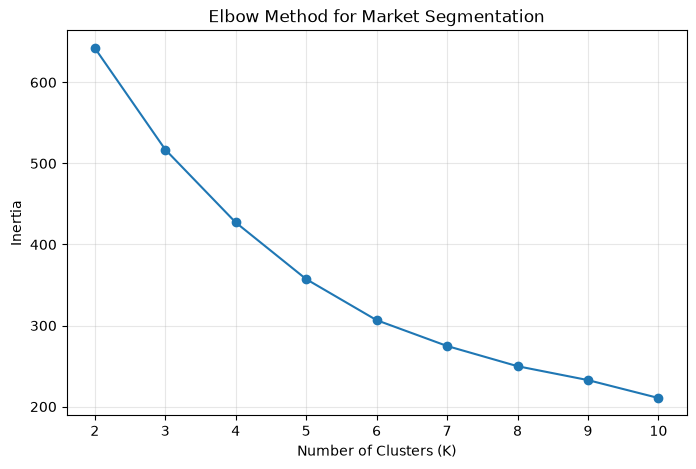

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Market Segmentation")

plt.xticks(k_values)
plt.grid(alpha=0.3)

plt.show()

In [55]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)

silhouette_scores

[0.4594019786574067,
 0.3061116229645038,
 0.26742147049604137,
 0.2874312178059026,
 0.3019022625384455,
 0.2850600865815324,
 0.28324636704550477,
 0.24785628177376806,
 0.2784465359843679]

In [56]:
candidate_ks = [2, 5, 6]

cluster_results = {}

for k in candidate_ks:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    cluster_results[k] = {
        "model": kmeans,
        "labels": labels
    }
    
    print(f"\n===== K = {k} =====")
    print(pd.Series(labels).value_counts().sort_index())


===== K = 2 =====
0    157
1     40
Name: count, dtype: int64

===== K = 5 =====
0    69
1    61
2    10
3    17
4    40
Name: count, dtype: int64

===== K = 6 =====
0    40
1    69
2    11
3     7
4    60
5    10
Name: count, dtype: int64


In [57]:
comparison_5_6 = pd.crosstab(
    cluster_results[5]["labels"],
    cluster_results[6]["labels"],
    rownames=["K=5"],
    colnames=["K=6"],
    margins=True,
    margins_name="Total"
)

comparison_5_6

K=6,0,1,2,3,4,5,Total
K=5,,,,,,,
0,0,69,0,0,0,0,69
1,0,0,0,0,60,1,61
2,0,0,0,7,0,3,10
3,1,0,11,0,0,5,17
4,39,0,0,0,0,1,40
Total,40,69,11,7,60,10,197


In [58]:
centers_5 = pd.DataFrame(
    cluster_results[5]["model"].cluster_centers_,
    columns=X.columns
)

centers_6 = pd.DataFrame(
    cluster_results[6]["model"].cluster_centers_,
    columns=X.columns
)

print("===== K = 5 Cluster Centers =====")
display(centers_5.round(2))

print("===== K = 6 Cluster Centers =====")
display(centers_6.round(2))

===== K = 5 Cluster Centers =====


,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
0,1.0100,-0.1500,-0.0900,-0.8800,0.5000
1,-0.4200,-0.1800,-0.5500,-0.0300,0.3000
2,-1.7600,-0.6200,-2.2100,2.2800,-2.6200
3,-1.2000,-0.3700,1.1600,1.5200,-2.0900
4,-0.1600,0.8600,1.0600,0.3500,0.2200


===== K = 6 Cluster Centers =====


,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
0,-0.1400,0.8000,1.1100,0.3900,0.2500
1,1.0100,-0.1500,-0.0900,-0.8800,0.5000
2,-1.3600,-1.3100,1.2500,1.5000,-2.1800
3,-1.9700,-1.8700,-2.1100,2.1900,-2.5700
4,-0.4200,-0.2000,-0.5200,-0.0400,0.3300
5,-1.0000,1.8200,-0.5300,1.5900,-2.2000


In [59]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and "destination" in obj.columns:
        print(name, obj.shape)

partner_monthly (4194, 7)
country_year (206, 7)
_6 (5, 7)
_7 (5, 7)
market_month_coverage (206, 3)
_9 (10, 3)
all_markets (206, 2)
full_panel (4944, 6)
_11 (5, 3)
_12 (5, 4)
_14 (5, 6)
panel_2024 (2472, 6)
monthly_features (206, 8)
_17 (5, 6)
_20 (10, 4)
h1_h2_features (206, 5)
_21 (5, 4)
_22 (10, 4)
export_reconciliation (206, 6)
_23 (10, 5)
market_feature_table (206, 7)
_24 (10, 7)
missing_markets (10, 7)
_28 (10, 6)
_29 (15, 3)
_30 (15, 3)
growth_diagnosis (206, 5)
_32 (20, 4)
_33 (20, 4)
market_feature_model (206, 13)
_34 (5, 10)
_36 (15, 5)
non_market_rows (7, 13)
_37 (12, 3)
_38 (7, 3)
model_data (197, 15)
_45 (15, 5)
_46 (15, 5)


In [60]:
print("model_data:", model_data.shape)
print("X_model:", X_model.shape)

print("\nmodel_data index equals X_model index:")
print(model_data.index.equals(X_model.index))

display(model_data.head())

model_data: (197, 15)
X_model: (197, 5)

model_data index equals X_model index:
True


,destination_code,destination,export_2024,monthly_cv_2024,active_month_ratio_2024,h2_h1_momentum_2024,growth_2024,export_2023,H1,H2,log_export_2024,growth_log_ratio,momentum_log_ratio,growth_symmetric_2024,momentum_symmetric_2024
0,4,Afghanistan,"2,533,001.0000",1.0076,0.7500,0.6854,0.0614,"2,386,507.0000","943,259.0000","1,589,742.0000",14.7449,0.0596,0.5220,0.0596,0.5104
1,8,Albania,"568,342.0000",1.2658,1.0000,-0.6816,-0.2098,"719,209.0000","431,075.0000","137,267.0000",13.2505,-0.2354,-1.1443,-0.2343,-1.0339
2,12,Algeria,"11,727,414.0000",0.9496,1.0000,-0.1463,-0.3686,"18,573,541.0000","6,326,390.0000","5,401,024.0000",16.2774,-0.4598,-0.1581,-0.4519,-0.1578
3,20,Andorra,"27,409.0000",3.1256,0.2500,-0.8981,-0.5935,"67,429.0000","24,875.0000","2,534.0000",10.2187,-0.9002,-2.2837,-0.8440,-1.6302
4,24,Angola,"2,960,042.0000",1.3749,1.0000,-0.1271,0.1749,"2,519,493.0000","1,580,454.0000","1,379,588.0000",14.9007,0.1611,-0.1359,0.1608,-0.1357


In [61]:
model_data.columns.tolist()

['destination_code',
 'destination',
 'export_2024',
 'monthly_cv_2024',
 'active_month_ratio_2024',
 'h2_h1_momentum_2024',
 'growth_2024',
 'export_2023',
 'H1',
 'H2',
 'log_export_2024',
 'growth_log_ratio',
 'momentum_log_ratio',
 'growth_symmetric_2024',
 'momentum_symmetric_2024']

In [62]:
markets_k6 = model_data.copy()

markets_k6["cluster"] = cluster_results[6]["labels"]

markets_k6[["destination", "cluster"]].head(10)

,destination,cluster
0,Afghanistan,4
1,Albania,4
2,Algeria,4
3,Andorra,3
4,Angola,4
5,Antigua and Barbuda,4
6,Argentina,1
7,Australia,1
8,Austria,1
9,Bahamas,0


In [63]:
cols_to_show = [
    "destination",
    "export_2024",
    "growth_2024",
    "h2_h1_momentum_2024",
    "monthly_cv_2024",
    "active_month_ratio_2024",
    "cluster"
]

for c in [2, 3, 5]:
    print(f"\n===== Cluster {c} =====")
    
    display(
        markets_k6.loc[
            markets_k6["cluster"] == c,
            cols_to_show
        ].sort_values(
            "export_2024",
            ascending=False
        )
    )


===== Cluster 2 =====


,destination,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024,cluster
174,Sudan,"3,747,528.0000",-0.3560,0.1778,1.9969,0.4167,2
55,Eritrea,"1,536,860.0000",-0.4758,35.0596,2.2354,0.5000,2
68,Kiribati,"603,503.0000",-0.4560,10.7623,2.7258,0.3333,2
136,FS Micronesia,"437,289.0000",-0.0213,15.9334,2.2398,0.5833,2
26,Burundi,"235,966.0000",-0.9140,1.2877,1.7788,0.5833,2
176,Eswatini,"209,594.0000",-0.2392,0.2537,2.0687,0.4167,2
22,Br. Virgin Isds,"206,636.0000",-0.6292,0.3521,2.0491,0.2500,2
154,Saint Kitts and Nevis,"71,230.0000",-0.0600,NaN,2.8006,0.2500,2
189,Turks and Caicos Isds,"37,186.0000",-0.9604,9.3303,2.4295,0.2500,2
157,San Marino,"4,650.0000",-0.7901,NaN,3.4641,0.0833,2



===== Cluster 3 =====


,destination,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024,cluster
32,Cayman Isds,"639,507.0000",-0.8814,-0.9004,3.0898,0.4167,3
15,Bhutan,"504,638.0000",-0.3764,-0.7960,2.7675,0.4167,3
188,Turkmenistan,"32,656.0000",-0.9767,-0.9728,3.3561,0.2500,3
3,Andorra,"27,409.0000",-0.5935,-0.8981,3.1256,0.2500,3
53,Equatorial Guinea,"5,313.0000",-0.9937,-0.9293,3.2225,0.1667,3
41,Cook Isds,"2,615.0000",-0.1045,-0.6090,2.5903,0.1667,3
158,Sao Tome and Principe,920.0000,-0.9770,-0.6330,2.6188,0.1667,3



===== Cluster 5 =====


,destination,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024,cluster
173,South Sudan,"5,081,968.0000",2.0515,-0.8041,1.7576,0.5833,5
121,Nauru,"2,349,396.0000",NaN,22.2719,3.3017,0.2500,5
38,Comoros,"1,769,636.0000","5,634.7834",-0.7026,2.6702,0.5000,5
96,Lesotho,"1,577,600.0000",30.5861,2.7200,1.9195,0.3333,5
183,Tonga,"333,114.0000",125.9973,0.1764,1.6684,0.5000,5
156,Saint Vincent and the Grenadines,"196,495.0000",1.3782,1.6081,2.0181,0.5000,5
57,Faroe Isds,"195,548.0000",NaN,-1.0000,3.4641,0.0833,5
202,Samoa,"185,826.0000",5.5298,0.6500,2.2566,0.2500,5
31,Cabo Verde,"161,972.0000",2.5937,0.5419,2.1906,0.4167,5
14,Bermuda,"25,775.0000",NaN,-1.0000,3.4641,0.0833,5


In [64]:
business_profile_k6 = (
    markets_k6
    .groupby("cluster")
    .agg(
        market_count=("destination", "count"),
        median_export_2024=("export_2024", "median"),
        median_growth_2024=("growth_2024", "median"),
        median_momentum_2024=("h2_h1_momentum_2024", "median"),
        median_monthly_cv=("monthly_cv_2024", "median"),
        median_active_month_ratio=("active_month_ratio_2024", "median")
    )
    .round(4)
)

business_profile_k6

,market_count,median_export_2024,median_growth_2024,median_momentum_2024,median_monthly_cv,median_active_month_ratio
cluster,,,,,,
0,40,"7,540,335.0000",1.3096,2.7964,1.2639,1.0000
1,69,"182,795,717.0000",0.1088,0.2098,0.3855,1.0000
2,11,"209,594.0000",-0.4758,9.3303,2.2398,0.3333
3,7,"27,409.0000",-0.8814,-0.8981,3.0898,0.2500
4,60,"2,954,659.0000",0.0688,-0.0638,1.0889,1.0000
5,10,"264,804.5000",5.5298,0.3591,2.2236,0.3750


In [65]:
from sklearn.metrics import adjusted_rand_score

reference_labels = cluster_results[6]["labels"]

seeds = [1, 10, 42, 100, 2026]

stability_results = []

for seed in seeds:
    model = KMeans(
        n_clusters=6,
        random_state=seed,
        n_init=20
    )
    
    labels = model.fit_predict(X_scaled)
    
    ari = adjusted_rand_score(reference_labels, labels)
    
    stability_results.append({
        "random_state": seed,
        "ARI_vs_reference": ari,
        "inertia": model.inertia_
    })

stability_df = pd.DataFrame(stability_results)

stability_df

,random_state,ARI_vs_reference,inertia
0,1,0.9562,306.8846
1,10,1.0000,306.6477
2,42,1.0000,306.6477
3,100,0.9828,306.6693
4,2026,1.0000,306.6477


In [66]:
final_kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20
)

final_labels = final_kmeans.fit_predict(X_scaled)

In [67]:
market_segments = model_data.copy()

market_segments["cluster"] = final_labels

In [68]:
market_segments.shape

(197, 16)

In [69]:
cluster_name_map = {
    0: "加速扩张机会市场",
    1: "成熟核心市场",
    2: "低基数恢复市场",
    3: "边缘收缩市场",
    4: "一般稳定市场",
    5: "脉冲式高增长市场"
}

market_segments["segment"] = (
    market_segments["cluster"]
    .map(cluster_name_map)
)

In [70]:
market_segments[
    ["destination", "cluster", "segment"]
].head(20)

,destination,cluster,segment
0,Afghanistan,4,一般稳定市场
1,Albania,4,一般稳定市场
2,Algeria,4,一般稳定市场
3,Andorra,3,边缘收缩市场
4,Angola,4,一般稳定市场
5,Antigua and Barbuda,4,一般稳定市场
6,Argentina,1,成熟核心市场
7,Australia,1,成熟核心市场
8,Austria,1,成熟核心市场
9,Bahamas,0,加速扩张机会市场


In [71]:
growth_opportunities = (
    market_segments.loc[
        market_segments["cluster"] == 0,
        [
            "destination",
            "export_2024",
            "growth_2024",
            "h2_h1_momentum_2024",
            "monthly_cv_2024",
            "active_month_ratio_2024"
        ]
    ]
    .sort_values(
        "export_2024",
        ascending=False
    )
)

growth_opportunities

,destination,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
200,Uzbekistan,"146,837,513.0000",13.3031,14.5531,1.4954,1.0000
114,Mongolia,"63,852,471.0000",0.2213,34.7817,2.0735,1.0000
97,Latvia,"46,507,639.0000",35.0753,8.7411,2.2142,1.0000
81,Iraq,"41,527,908.0000",1.8561,1.3796,0.6915,1.0000
161,Serbia,"36,997,999.0000",20.0726,7.7700,1.3775,1.0000
204,Zambia,"34,999,502.0000",7.0632,7.3059,1.1541,0.9167
67,Ghana,"28,610,094.0000",1.8110,1.7227,1.5932,1.0000
40,Dem. Rep. of the Congo,"26,547,467.0000",0.3437,1.4373,1.6068,1.0000
50,Dominican Rep.,"23,300,139.0000",0.1825,3.3949,1.2320,1.0000
160,Senegal,"22,876,993.0000",2.3465,1.9530,0.8307,1.0000


In [72]:
for c in [0, 1, 4]:
    print(f"\n===== Cluster {c} =====")
    
    display(
        market_segments.loc[
            market_segments["cluster"] == c,
            [
                "destination",
                "export_2024",
                "growth_2024",
                "h2_h1_momentum_2024",
                "monthly_cv_2024",
                "active_month_ratio_2024"
            ]
        ]
        .sort_values("export_2024", ascending=False)
        .head(15)
    )


===== Cluster 0 =====


,destination,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
200,Uzbekistan,"146,837,513.0000",13.3031,14.5531,1.4954,1.0000
114,Mongolia,"63,852,471.0000",0.2213,34.7817,2.0735,1.0000
97,Latvia,"46,507,639.0000",35.0753,8.7411,2.2142,1.0000
81,Iraq,"41,527,908.0000",1.8561,1.3796,0.6915,1.0000
161,Serbia,"36,997,999.0000",20.0726,7.7700,1.3775,1.0000
204,Zambia,"34,999,502.0000",7.0632,7.3059,1.1541,0.9167
67,Ghana,"28,610,094.0000",1.8110,1.7227,1.5932,1.0000
40,Dem. Rep. of the Congo,"26,547,467.0000",0.3437,1.4373,1.6068,1.0000
50,Dominican Rep.,"23,300,139.0000",0.1825,3.3949,1.2320,1.0000
160,Senegal,"22,876,993.0000",2.3465,1.9530,0.8307,1.0000



===== Cluster 1 =====


,destination,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
197,USA,"15,336,139,169.0000",0.1306,0.6199,0.2870,1.0000
66,Germany,"10,254,026,944.0000",0.0984,0.0270,0.1227,1.0000
91,Rep. of Korea,"3,788,155,735.0000",-0.5175,-0.0371,0.1879,1.0000
167,Viet Nam,"3,709,583,575.0000",0.1295,0.0722,0.1930,1.0000
124,Netherlands,"2,407,019,653.0000",-0.3387,0.2655,0.2168,1.0000
87,Japan,"2,327,215,411.0000",-0.0408,-0.0504,0.1402,1.0000
164,India,"2,158,380,442.0000",-0.0193,0.2098,0.1697,1.0000
195,United Kingdom,"1,630,275,744.0000",0.0264,0.0498,0.2590,1.0000
7,Australia,"1,456,510,643.0000",1.0122,2.0620,0.6845,1.0000
172,Spain,"1,170,299,687.0000",-0.3723,0.1091,0.3876,1.0000



===== Cluster 4 =====


,destination,export_2024,growth_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
129,New Zealand,"83,120,484.0000",1.5020,-0.6960,1.1019,1.0000
117,Morocco,"33,043,099.0000",-0.1932,-0.6503,0.8358,1.0000
80,Iran,"25,529,245.0000",1.1926,-0.2585,1.1159,1.0000
103,Madagascar,"17,930,727.0000",1.4687,-0.5333,1.0027,1.0000
27,Belarus,"14,252,727.0000",0.2854,-0.1977,1.4832,1.0000
198,Burkina Faso,"14,114,746.0000",1.2182,-0.3136,0.5844,1.0000
35,Chad,"13,587,494.0000",1.1410,-0.3258,1.0151,1.0000
2,Algeria,"11,727,414.0000",-0.3686,-0.1463,0.9496,1.0000
34,Sri Lanka,"10,341,816.0000",0.8302,0.5030,0.8158,1.0000
99,Libya,"8,492,317.0000",-0.1086,0.5799,1.2623,1.0000


In [73]:
score_data = market_segments.copy()

score_data["scale_score"] = (
    score_data["log_export_2024"].rank(pct=True) * 100
)

score_data["growth_score"] = (
    score_data["growth_symmetric_2024"].rank(pct=True) * 100
)

score_data["momentum_score"] = (
    score_data["momentum_symmetric_2024"].rank(pct=True) * 100
)

score_data["activity_score"] = (
    score_data["active_month_ratio_2024"].rank(pct=True) * 100
)

score_data["stability_score"] = (
    100
    - score_data["monthly_cv_2024"].rank(pct=True) * 100
)

In [74]:
score_data["market_scale"] = score_data["scale_score"]

score_data["growth_momentum"] = (
    score_data["growth_score"]
    + score_data["momentum_score"]
) / 2

score_data["growth_quality"] = (
    score_data["activity_score"]
    + score_data["stability_score"]
) / 2

In [75]:
score_data[
    [
        "destination",
        "segment",
        "market_scale",
        "growth_momentum",
        "growth_quality"
    ]
].head(20)

,destination,segment,market_scale,growth_momentum,growth_quality
0,Afghanistan,一般稳定市场,31.9797,53.0457,34.2640
1,Albania,一般稳定市场,16.7513,15.4822,48.6041
2,Algeria,一般稳定市场,54.3147,19.5431,58.7563
3,Andorra,边缘收缩市场,3.5533,4.8223,4.1878
4,Angola,一般稳定市场,36.0406,38.0711,47.3350
5,Antigua and Barbuda,一般稳定市场,11.6751,61.4213,24.3655
6,Argentina,成熟核心市场,75.6345,31.7259,59.2640
7,Australia,成熟核心市场,95.9391,79.9492,63.3249
8,Austria,成熟核心市场,82.7411,41.3706,65.8629
9,Bahamas,加速扩张机会市场,20.8122,72.5888,50.1269


In [76]:
# 复制评分数据，避免直接修改上游结果
score_df = score_data.copy()

# 定义：把任意指标转成 0~100 的百分位分数
def percentile_score(series, higher_is_better=True):
    rank = series.rank(method="average", ascending=True)
    n = rank.notna().sum()

    score = (rank - 1) / (n - 1) * 100

    # 如果指标是“越小越好”，把分数反过来
    if not higher_is_better:
        score = 100 - score

    return score


# 1. 市场规模：越大越好
score_df["size_score"] = percentile_score(
    score_df["export_2024"]
)

# 2. 同比增长：越大越好
score_df["growth_score"] = percentile_score(
    score_df["growth_2024"]
)

# 3. 半年动量：越大越好
score_df["momentum_score"] = percentile_score(
    score_df["h2_h1_momentum_2024"]
)

# 4. 月度波动率：越小越好
score_df["stability_score"] = percentile_score(
    score_df["monthly_cv_2024"],
    higher_is_better=False
)

# 5. 活跃月份比例：越大越好
score_df["activity_score"] = percentile_score(
    score_df["active_month_ratio_2024"]
)

In [77]:
score_df[
    [
        "destination",
        "cluster",
        "size_score",
        "growth_score",
        "momentum_score",
        "stability_score",
        "activity_score"
    ]
].head(20)

,destination,cluster,size_score,growth_score,momentum_score,stability_score,activity_score
0,Afghanistan,4,31.6327,39.8964,67.0103,51.0204,17.3469
1,Albania,4,16.3265,24.3523,6.1856,32.6531,64.5408
2,Algeria,4,54.0816,16.0622,22.6804,53.0612,64.5408
3,Andorra,3,3.0612,6.2176,2.5773,3.0612,4.8469
4,Angola,4,35.7143,52.3316,24.2268,30.1020,64.5408
5,Antigua and Barbuda,4,11.2245,60.6218,63.4021,31.1224,17.3469
6,Argentina,1,75.5102,26.9430,36.5979,54.0816,64.5408
7,Australia,1,95.9184,76.1658,85.5670,62.2449,64.5408
8,Austria,1,82.6531,8.2902,74.7423,67.3469,64.5408
9,Bahamas,0,20.4082,75.1295,71.6495,35.7143,64.5408


In [78]:
score_df["growth_score"] = percentile_score(
    score_df["growth_symmetric_2024"]
)

In [79]:
score_df["growth_score"].isna().sum()

np.int64(0)

In [80]:
weights = {
    "size_score": 0.30,
    "growth_score": 0.25,
    "momentum_score": 0.20,
    "stability_score": 0.15,
    "activity_score": 0.10
}

score_df["opportunity_score"] = (
    score_df["size_score"] * weights["size_score"]
    + score_df["growth_score"] * weights["growth_score"]
    + score_df["momentum_score"] * weights["momentum_score"]
    + score_df["stability_score"] * weights["stability_score"]
    + score_df["activity_score"] * weights["activity_score"]
)

In [81]:
top20_markets = (
    score_df[
        [
            "destination",
            "cluster",
            "size_score",
            "growth_score",
            "momentum_score",
            "stability_score",
            "activity_score",
            "opportunity_score"
        ]
    ]
    .sort_values("opportunity_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

top20_markets

,destination,cluster,size_score,growth_score,momentum_score,stability_score,activity_score,opportunity_score
0,France,1,94.3878,87.2449,56.7010,89.2857,64.5408,81.3147
1,Australia,1,95.9184,75.0000,85.5670,62.2449,64.5408,80.4297
2,Uzbekistan,0,81.1224,95.9184,95.8763,27.0408,64.5408,78.0018
3,Romania,1,79.5918,91.3265,62.8866,80.1020,64.5408,77.7559
4,Ukraine,1,80.6122,82.1429,81.4433,64.7959,64.5408,77.1815
5,Saudi Arabia,1,92.3469,83.6735,73.1959,36.7347,64.5408,75.2259
6,USA,1,100.0000,47.4490,65.4639,89.7959,64.5408,74.8785
7,Hungary,1,93.8776,64.7959,55.1546,86.2245,64.5408,74.7809
8,United Arab Emirates,1,84.1837,74.4898,53.0928,88.2653,64.5408,74.1900
9,Serbia,0,68.3673,96.4286,92.2680,28.5714,64.5408,73.8108


In [82]:
cluster_score_summary = (
    score_df
    .groupby("cluster")
    .agg(
        market_count=("destination", "count"),
        avg_opportunity_score=("opportunity_score", "mean"),
        avg_size_score=("size_score", "mean"),
        avg_growth_score=("growth_score", "mean"),
        avg_momentum_score=("momentum_score", "mean"),
        avg_stability_score=("stability_score", "mean"),
        avg_activity_score=("activity_score", "mean")
    )
    .round(2)
    .sort_values("avg_opportunity_score", ascending=False)
)

cluster_score_summary

,market_count,avg_opportunity_score,avg_size_score,avg_growth_score,avg_momentum_score,avg_stability_score,avg_activity_score
cluster,,,,,,,
1,69,63.4800,80.9400,45.1300,47.1000,80.2800,64.5400
0,40,59.5900,45.3700,75.1800,85.4100,33.8000,50.2700
5,10,40.1000,17.5500,93.8800,44.7900,11.0500,7.5000
4,60,39.6700,34.9600,43.1500,31.7100,44.8700,53.2100
2,11,25.8700,12.2900,13.3600,78.4700,11.2000,7.6100
3,7,5.6800,5.9800,7.7300,3.8300,4.6600,4.8800


In [83]:
top_markets_by_cluster = (
    score_df
    .sort_values(
        ["cluster", "opportunity_score"],
        ascending=[True, False]
    )
    .groupby("cluster")
    .head(5)
    [
        [
            "cluster",
            "destination",
            "opportunity_score",
            "size_score",
            "growth_score",
            "momentum_score",
            "stability_score",
            "activity_score"
        ]
    ]
    .reset_index(drop=True)
)

top_markets_by_cluster

,cluster,destination,opportunity_score,size_score,growth_score,momentum_score,stability_score,activity_score
0,0,Uzbekistan,78.0018,81.1224,95.9184,95.8763,27.0408,64.5408
1,0,Serbia,73.8108,68.3673,96.4286,92.2680,28.5714,64.5408
2,0,Iraq,73.7303,70.9184,84.6939,77.8351,61.7347,64.5408
3,0,Latvia,73.2771,72.9592,97.4490,93.2990,12.7551,64.5408
4,0,Yemen,73.1030,57.6531,93.3673,82.9897,62.7551,64.5408
5,1,France,81.3147,94.3878,87.2449,56.7010,89.2857,64.5408
6,1,Australia,80.4297,95.9184,75.0000,85.5670,62.2449,64.5408
7,1,Romania,77.7559,79.5918,91.3265,62.8866,80.1020,64.5408
8,1,Ukraine,77.1815,80.6122,82.1429,81.4433,64.7959,64.5408
9,1,Saudi Arabia,75.2259,92.3469,83.6735,73.1959,36.7347,64.5408


In [84]:
cluster_labels = {
    0: "高增长机会市场",
    1: "成熟核心市场",
    2: "低活跃脉冲市场",
    3: "边缘沉寂市场",
    4: "常规培育市场",
    5: "低基数暴增市场"
}

score_df["market_segment"] = score_df["cluster"].map(cluster_labels)

In [85]:
top20_markets = (
    score_df[
        [
            "destination",
            "cluster",
            "market_segment",
            "opportunity_score",
            "size_score",
            "growth_score",
            "momentum_score",
            "stability_score",
            "activity_score"
        ]
    ]
    .sort_values("opportunity_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

top20_markets

,destination,cluster,market_segment,opportunity_score,size_score,growth_score,momentum_score,stability_score,activity_score
0,France,1,成熟核心市场,81.3147,94.3878,87.2449,56.7010,89.2857,64.5408
1,Australia,1,成熟核心市场,80.4297,95.9184,75.0000,85.5670,62.2449,64.5408
2,Uzbekistan,0,高增长机会市场,78.0018,81.1224,95.9184,95.8763,27.0408,64.5408
3,Romania,1,成熟核心市场,77.7559,79.5918,91.3265,62.8866,80.1020,64.5408
4,Ukraine,1,成熟核心市场,77.1815,80.6122,82.1429,81.4433,64.7959,64.5408
5,Saudi Arabia,1,成熟核心市场,75.2259,92.3469,83.6735,73.1959,36.7347,64.5408
6,USA,1,成熟核心市场,74.8785,100.0000,47.4490,65.4639,89.7959,64.5408
7,Hungary,1,成熟核心市场,74.7809,93.8776,64.7959,55.1546,86.2245,64.5408
8,United Arab Emirates,1,成熟核心市场,74.1900,84.1837,74.4898,53.0928,88.2653,64.5408
9,Serbia,0,高增长机会市场,73.8108,68.3673,96.4286,92.2680,28.5714,64.5408


In [86]:
# 根据市场类型增加决策层标签
decision_map = {
    0: "重点候选",      # 高增长机会市场
    1: "重点候选",      # 成熟核心市场
    4: "培育候选",      # 常规培育市场
    2: "观察名单",      # 低活跃脉冲市场
    5: "观察名单",      # 低基数暴增市场
    3: "低优先级"       # 边缘沉寂市场
}

score_df["decision_tier"] = score_df["cluster"].map(decision_map)

In [87]:
priority_markets = (
    score_df[
        score_df["decision_tier"] == "重点候选"
    ]
    [
        [
            "destination",
            "market_segment",
            "decision_tier",
            "opportunity_score",
            "size_score",
            "growth_score",
            "momentum_score",
            "stability_score",
            "activity_score"
        ]
    ]
    .sort_values("opportunity_score", ascending=False)
    .reset_index(drop=True)
)

priority_markets.head(20)

,destination,market_segment,decision_tier,opportunity_score,size_score,growth_score,momentum_score,stability_score,activity_score
0,France,成熟核心市场,重点候选,81.3147,94.3878,87.2449,56.7010,89.2857,64.5408
1,Australia,成熟核心市场,重点候选,80.4297,95.9184,75.0000,85.5670,62.2449,64.5408
2,Uzbekistan,高增长机会市场,重点候选,78.0018,81.1224,95.9184,95.8763,27.0408,64.5408
3,Romania,成熟核心市场,重点候选,77.7559,79.5918,91.3265,62.8866,80.1020,64.5408
4,Ukraine,成熟核心市场,重点候选,77.1815,80.6122,82.1429,81.4433,64.7959,64.5408
5,Saudi Arabia,成熟核心市场,重点候选,75.2259,92.3469,83.6735,73.1959,36.7347,64.5408
6,USA,成熟核心市场,重点候选,74.8785,100.0000,47.4490,65.4639,89.7959,64.5408
7,Hungary,成熟核心市场,重点候选,74.7809,93.8776,64.7959,55.1546,86.2245,64.5408
8,United Arab Emirates,成熟核心市场,重点候选,74.1900,84.1837,74.4898,53.0928,88.2653,64.5408
9,Serbia,高增长机会市场,重点候选,73.8108,68.3673,96.4286,92.2680,28.5714,64.5408


In [88]:
check_top20 = (
    score_df[
        [
            "destination",
            "market_segment",
            "opportunity_score",
            "export_2024",
            "growth_symmetric_2024",
            "h2_h1_momentum_2024",
            "monthly_cv_2024",
            "active_month_ratio_2024"
        ]
    ]
    .sort_values("opportunity_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

check_top20

,destination,market_segment,opportunity_score,export_2024,growth_symmetric_2024,h2_h1_momentum_2024,monthly_cv_2024,active_month_ratio_2024
0,France,成熟核心市场,81.3147,"972,602,996.0000",1.0348,0.3876,0.3009,1.0000
1,Australia,成熟核心市场,80.4297,"1,456,510,643.0000",0.6721,2.0620,0.6845,1.0000
2,Uzbekistan,高增长机会市场,78.0018,"146,837,513.0000",1.7386,14.5531,1.4954,1.0000
3,Romania,成熟核心市场,77.7559,"142,004,192.0000",1.3165,0.5638,0.4241,1.0000
4,Ukraine,成熟核心市场,77.1815,"145,053,657.0000",0.8564,1.6711,0.6558,1.0000
5,Saudi Arabia,成熟核心市场,75.2259,"688,258,730.0000",0.9018,1.1162,1.2243,1.0000
6,USA,成熟核心市场,74.8785,"15,336,139,169.0000",0.1226,0.6199,0.2870,1.0000
7,Hungary,成熟核心市场,74.7809,"734,234,463.0000",0.3164,0.3722,0.3415,1.0000
8,United Arab Emirates,成熟核心市场,74.1900,"303,290,372.0000",0.6618,0.3454,0.3160,1.0000
9,Serbia,高增长机会市场,73.8108,"36,997,999.0000",1.8188,7.7700,1.3775,1.0000


## active_month_ratio 主要承担市场持续性验证作用，在成熟活跃市场中区分度有限。

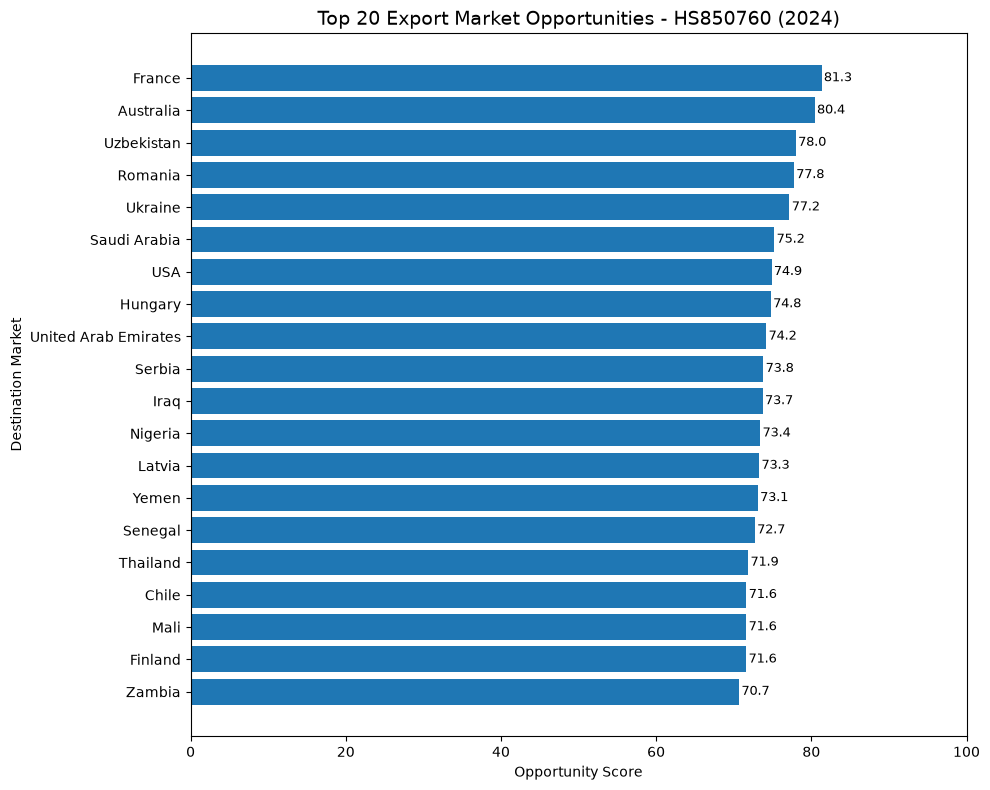

In [89]:
import matplotlib.pyplot as plt

# 取机会评分最高的 20 个市场
plot_top20 = (
    score_df
    .sort_values("opportunity_score", ascending=False)
    .head(20)
    .sort_values("opportunity_score", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    plot_top20["destination"],
    plot_top20["opportunity_score"]
)

ax.set_title(
    "Top 20 Export Market Opportunities - HS850760 (2024)",
    fontsize=14
)
ax.set_xlabel("Opportunity Score")
ax.set_ylabel("Destination Market")

# 在柱子右侧显示具体得分
for i, score in enumerate(plot_top20["opportunity_score"]):
    ax.text(
        score + 0.3,
        i,
        f"{score:.1f}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

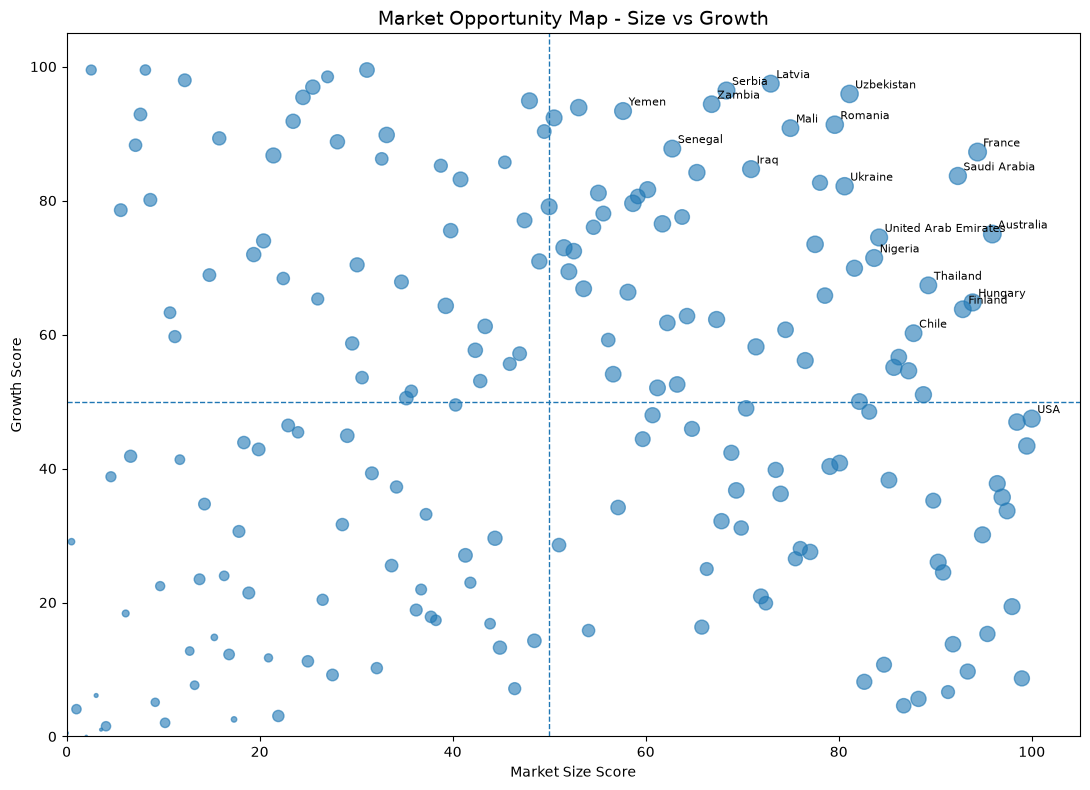

In [90]:
fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    score_df["size_score"],
    score_df["growth_score"],
    s=score_df["opportunity_score"] * 2,
    alpha=0.6
)

ax.set_title(
    "Market Opportunity Map - Size vs Growth",
    fontsize=14
)
ax.set_xlabel("Market Size Score")
ax.set_ylabel("Growth Score")

# 50 分作为大致中位线
ax.axvline(50, linestyle="--", linewidth=1)
ax.axhline(50, linestyle="--", linewidth=1)

# 只标注综合机会分最高的 20 个国家
label_markets = (
    score_df
    .sort_values("opportunity_score", ascending=False)
    .head(20)
)

for _, row in label_markets.iterrows():
    ax.annotate(
        row["destination"],
        (row["size_score"], row["growth_score"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlim(0, 105)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

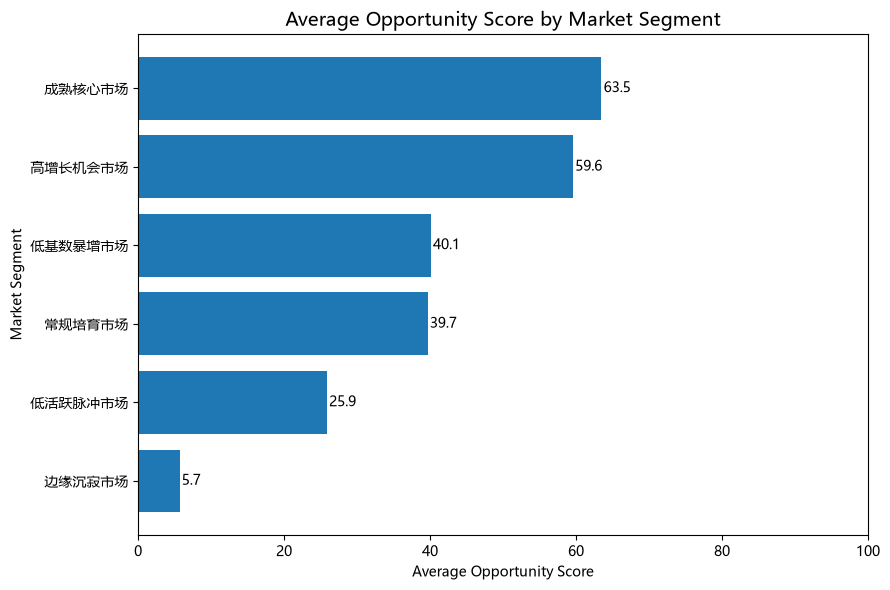

In [91]:
import matplotlib.pyplot as plt

# Windows 中文字体
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

cluster_plot = (
    score_df
    .groupby(["cluster", "market_segment"])["opportunity_score"]
    .mean()
    .reset_index()
    .sort_values("opportunity_score", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    cluster_plot["market_segment"],
    cluster_plot["opportunity_score"]
)

ax.set_title(
    "Average Opportunity Score by Market Segment",
    fontsize=14
)
ax.set_xlabel("Average Opportunity Score")
ax.set_ylabel("Market Segment")

for i, score in enumerate(cluster_plot["opportunity_score"]):
    ax.text(
        score + 0.3,
        i,
        f"{score:.1f}",
        va="center"
    )

ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [92]:
final_market_ranking = (
    score_df
    .sort_values("opportunity_score", ascending=False)
    .reset_index(drop=True)
    .copy()
)

final_market_ranking.insert(
    0,
    "opportunity_rank",
    range(1, len(final_market_ranking) + 1)
)

final_market_ranking[
    [
        "opportunity_rank",
        "destination",
        "market_segment",
        "decision_tier",
        "opportunity_score",
        "size_score",
        "growth_score",
        "momentum_score",
        "stability_score",
        "activity_score"
    ]
].head(20)

,opportunity_rank,destination,market_segment,decision_tier,opportunity_score,size_score,growth_score,momentum_score,stability_score,activity_score
0,1,France,成熟核心市场,重点候选,81.3147,94.3878,87.2449,56.7010,89.2857,64.5408
1,2,Australia,成熟核心市场,重点候选,80.4297,95.9184,75.0000,85.5670,62.2449,64.5408
2,3,Uzbekistan,高增长机会市场,重点候选,78.0018,81.1224,95.9184,95.8763,27.0408,64.5408
3,4,Romania,成熟核心市场,重点候选,77.7559,79.5918,91.3265,62.8866,80.1020,64.5408
4,5,Ukraine,成熟核心市场,重点候选,77.1815,80.6122,82.1429,81.4433,64.7959,64.5408
5,6,Saudi Arabia,成熟核心市场,重点候选,75.2259,92.3469,83.6735,73.1959,36.7347,64.5408
6,7,USA,成熟核心市场,重点候选,74.8785,100.0000,47.4490,65.4639,89.7959,64.5408
7,8,Hungary,成熟核心市场,重点候选,74.7809,93.8776,64.7959,55.1546,86.2245,64.5408
8,9,United Arab Emirates,成熟核心市场,重点候选,74.1900,84.1837,74.4898,53.0928,88.2653,64.5408
9,10,Serbia,高增长机会市场,重点候选,73.8108,68.3673,96.4286,92.2680,28.5714,64.5408


In [93]:
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# 全部市场最终结果
final_market_ranking.to_csv(
    output_dir / "market_opportunity_ranking_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

# 重点候选市场
priority_markets.to_csv(
    output_dir / "priority_export_markets_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Results exported successfully.")

Results exported successfully.


In [94]:
list(output_dir.iterdir())

[WindowsPath('outputs/final_market_validation_decision_2024.csv'),
 WindowsPath('outputs/market_opportunity_change_2023_2024.csv'),
 WindowsPath('outputs/market_opportunity_ranking_2024.csv'),
 WindowsPath('outputs/priority_export_markets_2024.csv'),
 WindowsPath('outputs/top_market_opportunity_risers_2024.csv')]

## Conclusion

本 Notebook 基于中国 HS850760 锂离子蓄电池 2023–2024 年目的国月度出口数据，
完成了出口市场特征工程、KMeans 市场分群和市场机会评分。

### 市场分群

KMeans 最终将出口市场划分为 6 类：

1. 成熟核心市场
2. 高增长机会市场
3. 常规培育市场
4. 低基数暴增市场
5. 低活跃脉冲市场
6. 边缘沉寂市场

聚类用于回答“市场属于什么类型”。

### 市场机会评分

在市场规模、增长、近期动量、稳定性和持续活跃度五个维度上，
采用 Percentile Score 转换为 0–100 分，并构建综合 Opportunity Score。

机会评分用于回答“市场当前值得多高的关注优先级”。

2024 年综合机会评分排名靠前的市场包括：

- France
- Australia
- Uzbekistan
- Romania
- Ukraine
- Saudi Arabia
- USA

其中，France、Australia 等主要体现成熟大市场机会，
而 Uzbekistan、Serbia、Iraq 等更多体现高增长型市场机会。

### 决策含义

最终形成：

市场特征 → 市场分群 → 机会评分 → 决策分层

的市场机会识别流程。

需要注意的是，本模型识别的是贸易数据层面的市场机会信号，
最终市场进入决策仍需结合关税、物流、政策、竞争格局和地缘风险等外部信息进一步验证。

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

model_objects = []

for name, obj in globals().items():
    if isinstance(obj, StandardScaler):
        model_objects.append(
            {
                "name": name,
                "type": "StandardScaler",
                "n_features": getattr(obj, "n_features_in_", None)
            }
        )

    elif isinstance(obj, KMeans):
        model_objects.append(
            {
                "name": name,
                "type": "KMeans",
                "n_clusters": obj.n_clusters,
                "n_features": getattr(obj, "n_features_in_", None)
            }
        )

model_objects

[{'name': 'scaler', 'type': 'StandardScaler', 'n_features': 5},
 {'name': 'kmeans', 'type': 'KMeans', 'n_clusters': 6, 'n_features': 5},
 {'name': 'model', 'type': 'KMeans', 'n_clusters': 6, 'n_features': 5},
 {'name': 'final_kmeans', 'type': 'KMeans', 'n_clusters': 6, 'n_features': 5}]

In [96]:
X_model.columns.tolist()

['log_export_2024',
 'growth_symmetric_2024',
 'momentum_symmetric_2024',
 'monthly_cv_2024',
 'active_month_ratio_2024']

In [97]:
import numpy as np

print(
    "final_kmeans:",
    np.array_equal(final_kmeans.labels_, score_data["cluster"].to_numpy())
)

print(
    "kmeans:",
    np.array_equal(kmeans.labels_, score_data["cluster"].to_numpy())
)

print(
    "model:",
    np.array_equal(model.labels_, score_data["cluster"].to_numpy())
)

final_kmeans: True
kmeans: True
model: False


In [98]:
# 封装保存

from pathlib import Path
import joblib

feature_cols = [
    "log_export_2024",
    "growth_symmetric_2024",
    "momentum_symmetric_2024",
    "monthly_cv_2024",
    "active_month_ratio_2024"
]

cluster_labels = {
    0: "高增长机会市场",
    1: "成熟核心市场",
    2: "低活跃脉冲市场",
    3: "边缘沉寂市场",
    4: "常规培育市场",
    5: "低基数暴增市场"
}

model_bundle = {
    "scaler": scaler,
    "kmeans": final_kmeans,
    "feature_cols": feature_cols,
    "cluster_labels": cluster_labels,
    "training_year": 2024,
    "hs_code": "850760"
}

model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

joblib.dump(
    model_bundle,
    model_dir / "market_segmentation_bundle.joblib"
)

print("Model bundle saved.")

Model bundle saved.


In [99]:
list(model_dir.iterdir())

[WindowsPath('models/market_segmentation_bundle.joblib')]